# Seoul Bike Data Final Report
Amelia Jiang-Yu: ajiangy1@jhu.edu  
Raj Gosain: rgosain3@jhu.edu

## 0 Introduction

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from scipy import stats



### a. Data Set

Link: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

The Seoul Bike Sharing Demand dataset details the number of public bicycles rented each hour via the Seoul Bike Sharing System. The dataset includes weather information such Temperature, Humidity, Windspeed, Visibility, Dewpoint, Solar radiation, Snowfall, and Rainfall. Other information includes the season, whether the day is a holiday or not, and whether the hour is functional or not.

The response variable is `Rented Bike Count` at each hour. Explanatory variables include:
- `Date`: categorical
- `Hour`: categorical
- `Temperature` (in Celsius): continuous
- `Humidity` (%): continuous
- `Wind Speed` (m/s): continuous
- `Visibility` (10 m): integer-valued
- `Dew Point Temperature` (in Celsius): continuous
- `Solar Radiation` (MJ/m2): continuous
- `Rainfall` (mm): continuous
- `Snowfall` (cm): continuous
- `Seasons`: categorical (winter, spring, summer, fall)
- `Holiday`: binary (holiday, no holiday)
- `Functioning Day`: binary (yes, no)

In [2]:
df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")
df['Hour'] = df['Hour'].astype('category')
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'].astype(str) + ':00', dayfirst=True)
df['Date_only'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df.shape)
df.head()

(8760, 16)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,DateTime,Date_only
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00,2017-12-01
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00,2017-12-01
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00,2017-12-01
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00,2017-12-01
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00,2017-12-01


### b. Data Visualization

In [3]:
continuous_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = ['Date', 'Hour', 'Seasons']
binary_cols = ['Holiday', 'Functioning Day']

print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)
print("Binary:", binary_cols)

Categorical: ['Date', 'Hour', 'Seasons']
Continuous: ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
Binary: ['Holiday', 'Functioning Day']


#### Categorical Variables
The categorical variables are:
- `Date`
- `Hour`
- `Season`

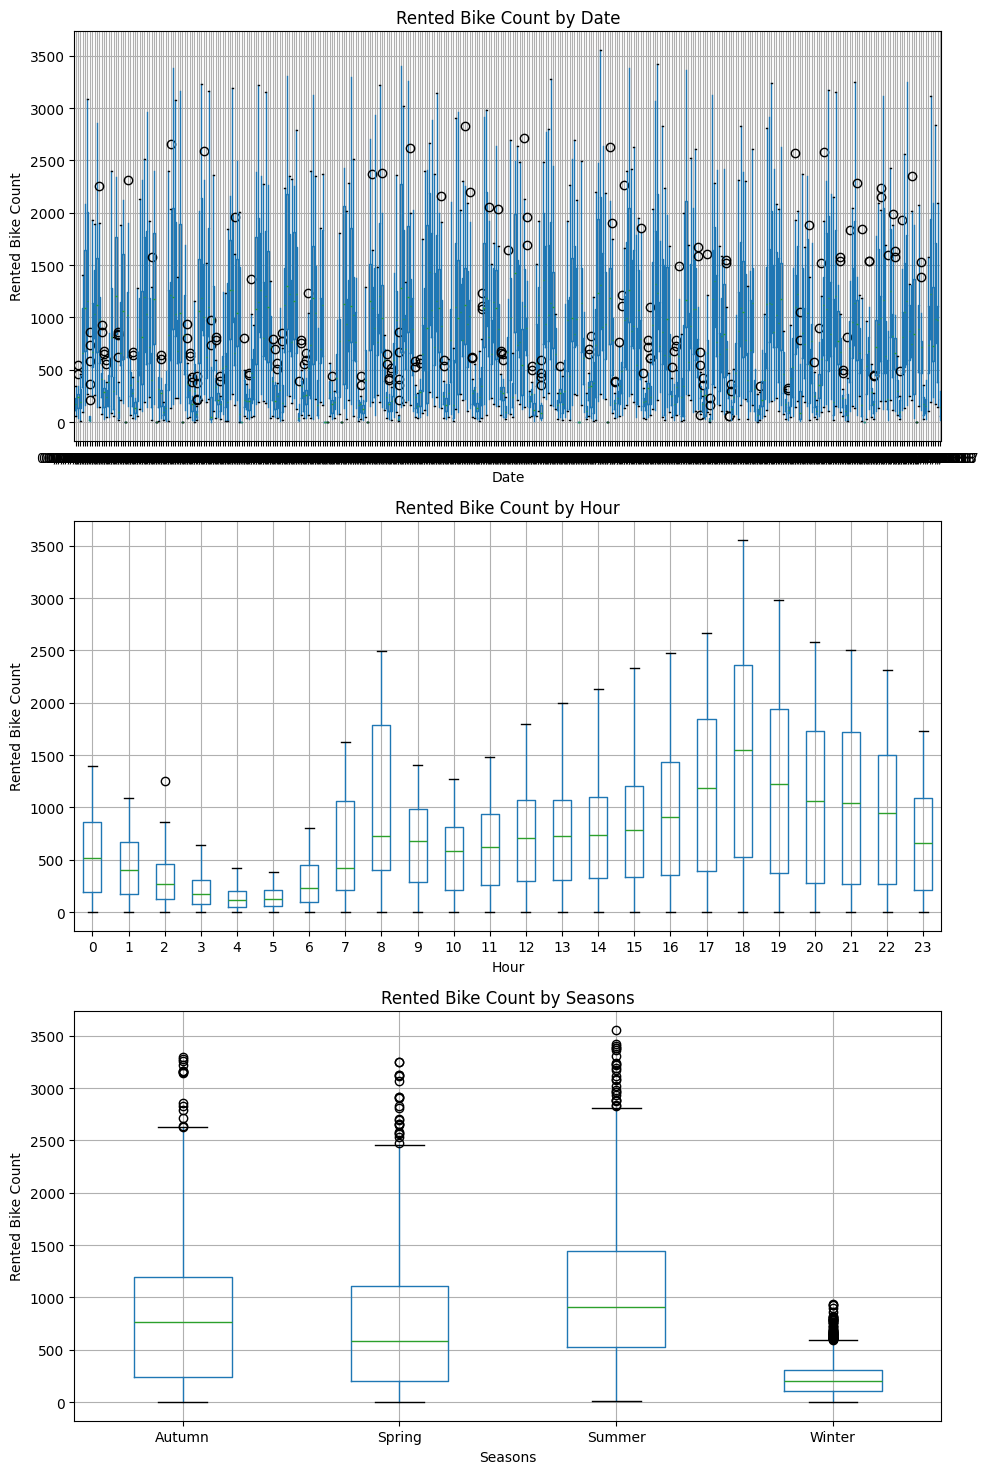

In [4]:
Y = 'Rented Bike Count'


fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs = axs.flatten()

i = 0
for col in categorical_cols:
    if col != Y:
        df.boxplot(column=Y, by=col, ax=axs[i])

        axs[i].set_title(f'{Y} by {col}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(Y)

        i += 1

# Remove the automatic "Boxplot grouped by ..." super-title
plt.suptitle("")

plt.tight_layout()
plt.show()


There is a spike in `Rented Bike Count` at the hours of **8** (8 am) and **18** (6 pm), which is consistent with when people generally go to work in the morning and return home in the evening. As expected, `Rented Bike Count` is higher in **Autumn**, **Spring**, and **Summer** compared to **Winter**.

#### Continuous Variables

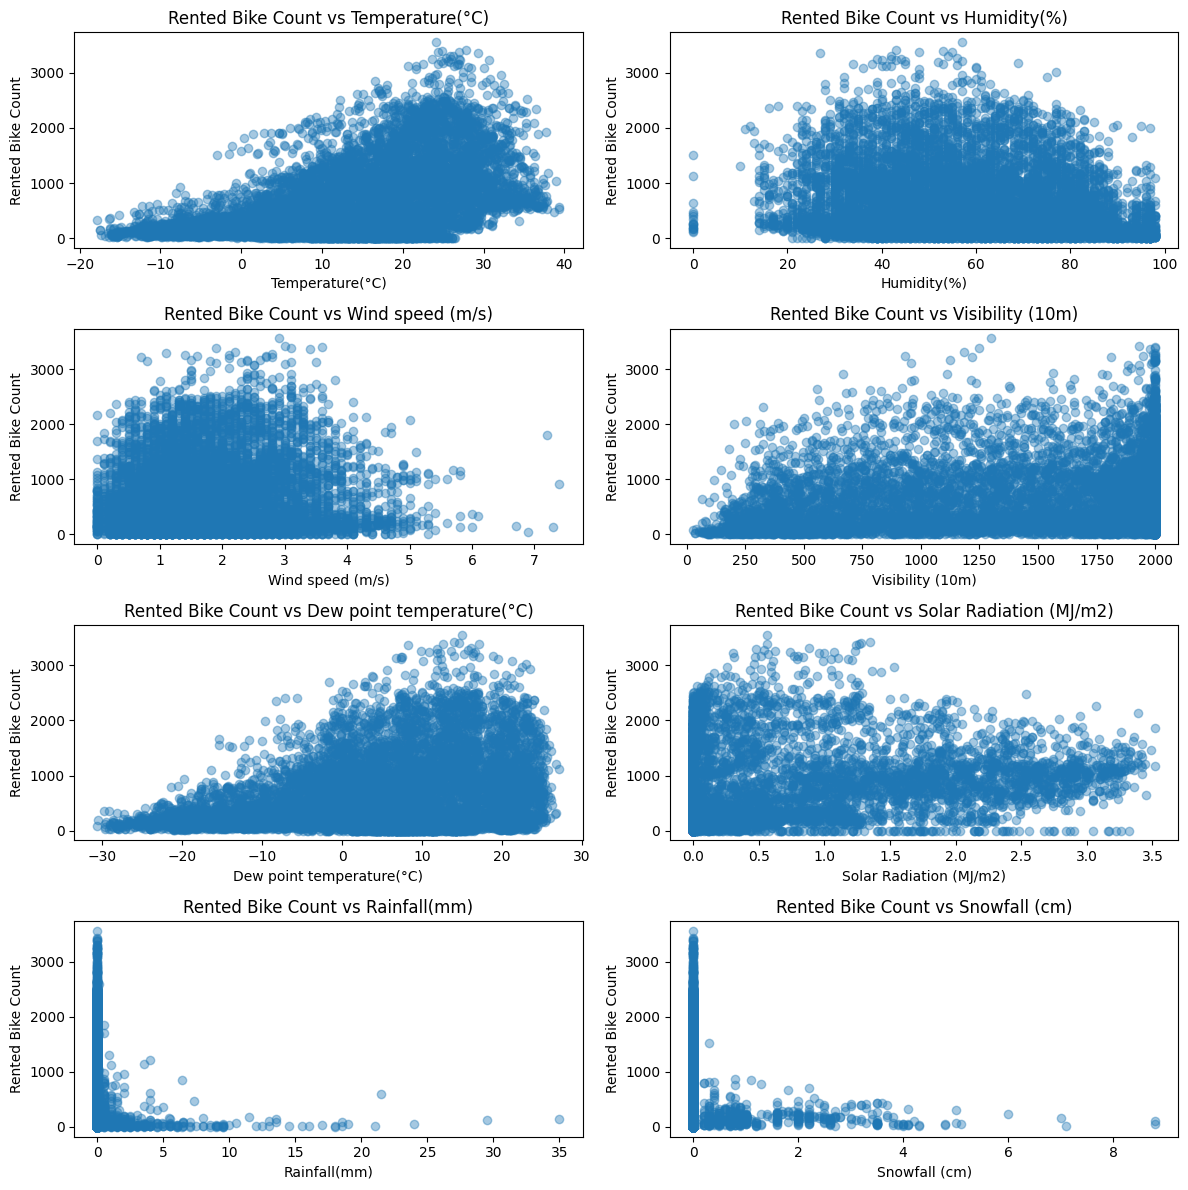

In [5]:
fig, axs = plt.subplots(4, 2, figsize=(12, 12))
axs = axs.flatten()   # flatten to make indexing easier

i = 0
for col in continuous_cols:
    if col != Y:
        ax = axs[i]
        ax.scatter(df[col], df[Y], alpha=0.4)
        ax.set_xlabel(col)
        ax.set_ylabel(Y)
        ax.set_title(f'{Y} vs {col}')
        i += 1

plt.tight_layout()
plt.show()


#### Binary Variables

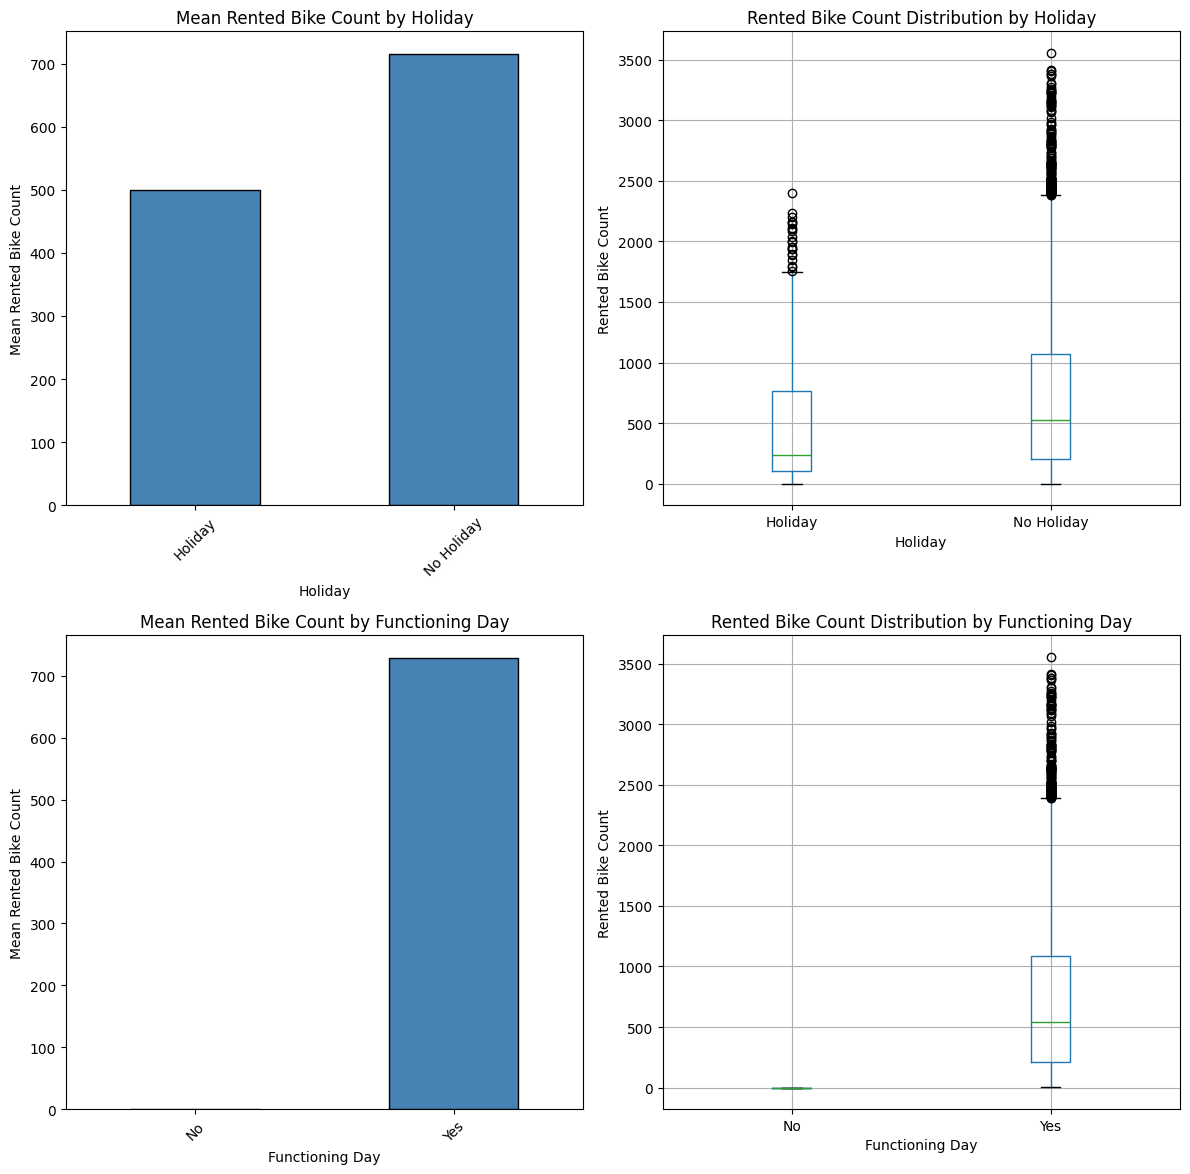

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

i = 0
for col in binary_cols:
    if col != Y:

        # --- Proportion bar plot ---
        prop = df.groupby(col)[Y].mean()
        ax = axs[i]

        prop.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
        ax.set_title(f'Mean {Y} by {col}')
        ax.set_ylabel(f'Mean {Y}')
        ax.set_xlabel(col)
        ax.set_xticks(range(len(prop.index)))
        ax.set_xticklabels(prop.index.astype(str), rotation=45)

        i += 1

        # --- Boxplot ---
        ax = axs[i]
        df.boxplot(column=Y, by=col, ax=ax)

        ax.set_title(f'{Y} Distribution by {col}')
        ax.set_xlabel(col)
        ax.set_ylabel(Y)

        # Remove the automatic "Boxplot grouped by col" super-title
        plt.suptitle("")

        i += 1

plt.tight_layout()
plt.show()



`Rented Bike Count` is generally higher on non-holiday days compared to holiday days. We can also see that `Rented Bike Count` is always zero (0) on non-functioning days.

### c. Descriptive Statistics

#### Categorical Variables

In [7]:
print(df[categorical_cols].describe(include='all'))

              Date  Hour Seasons
count         8760  8760    8760
unique         365    24       4
top     01/12/2017     0  Spring
freq            24   365    2208


With 365 unique dates, we can see that the data set extends for an exactly 1 year. Each date has 24 instances, one for each hour. Each hour has 365 instances, one for each date.

#### Continuous Variables

In [8]:
print(df[continuous_cols].describe(include='all'))

       Rented Bike Count  Temperature(°C)  Humidity(%)  Wind speed (m/s)  \
count        8760.000000      8760.000000  8760.000000       8760.000000   
mean          704.602055        12.882922    58.226256          1.724909   
std           644.997468        11.944825    20.362413          1.036300   
min             0.000000       -17.800000     0.000000          0.000000   
25%           191.000000         3.500000    42.000000          0.900000   
50%           504.500000        13.700000    57.000000          1.500000   
75%          1065.250000        22.500000    74.000000          2.300000   
max          3556.000000        39.400000    98.000000          7.400000   

       Visibility (10m)  Dew point temperature(°C)  Solar Radiation (MJ/m2)  \
count       8760.000000                8760.000000              8760.000000   
mean        1436.825799                   4.073813                 0.569111   
std          608.298712                  13.060369                 0.868746   

Mean `Rented Bike Count` is 704.6. The minumum is 0 and the maximum is 3556.

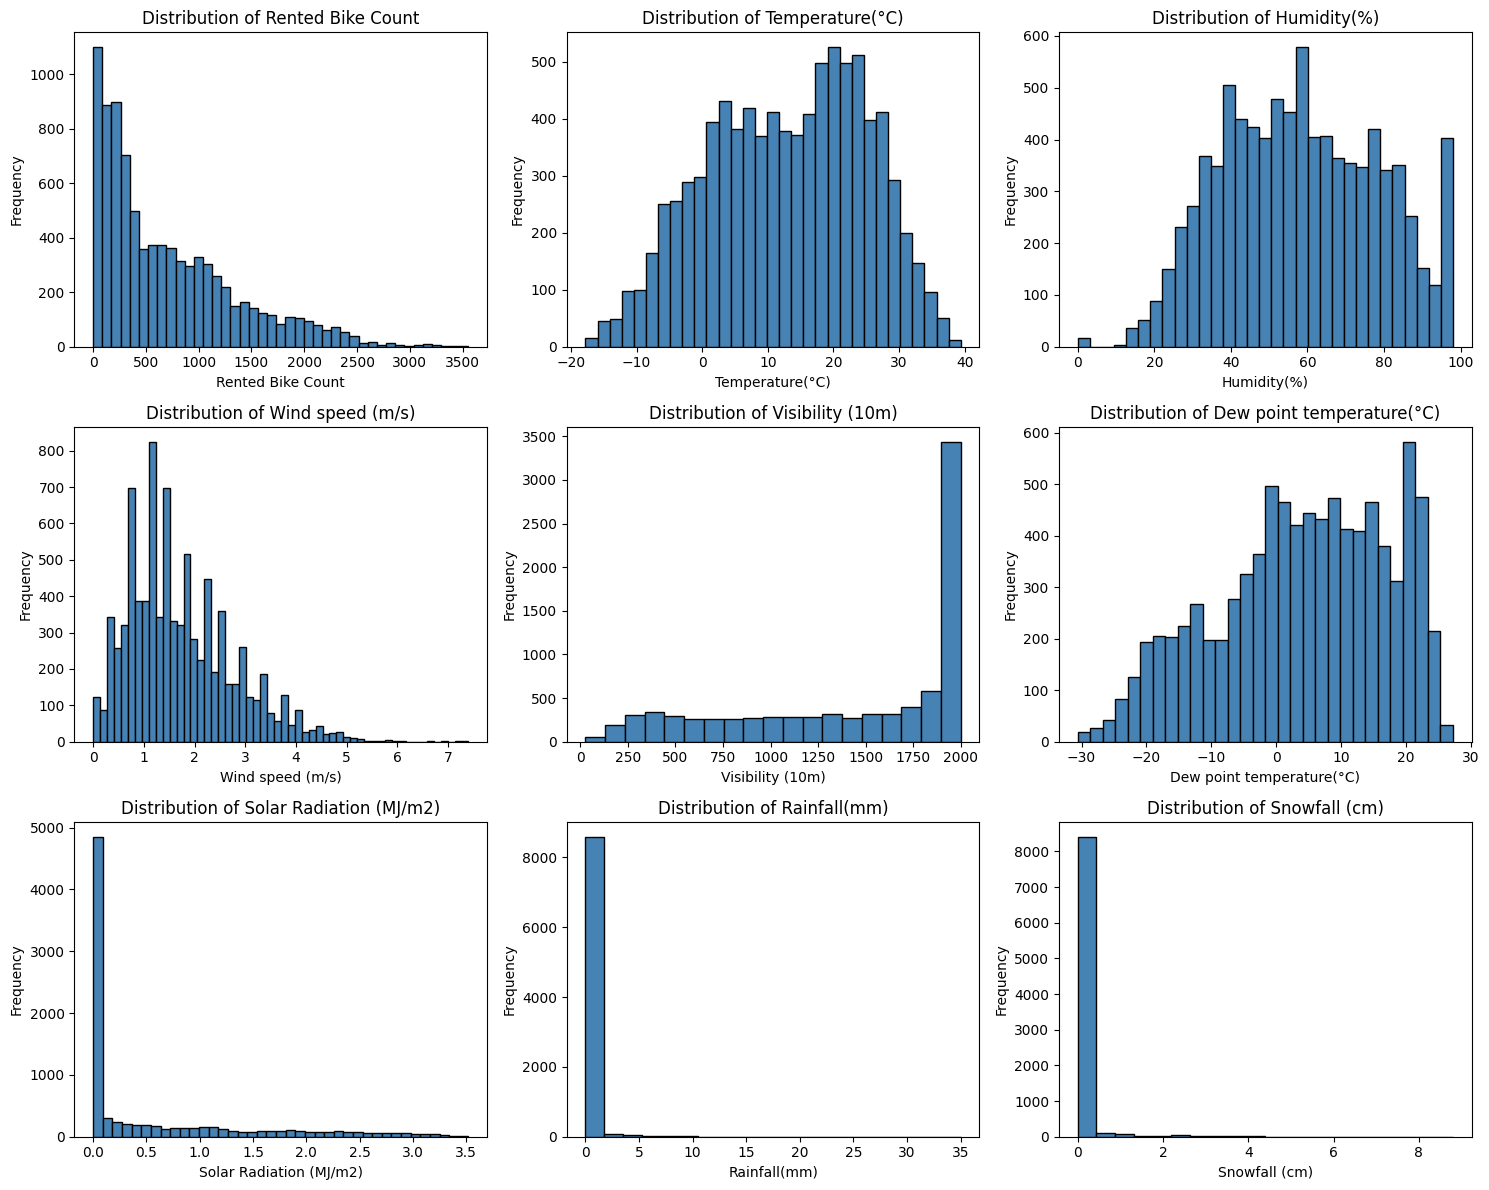

In [9]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs = axs.flatten()

for i, col in enumerate(continuous_cols):

    # Freedman–Diaconis rule for optimal bin width
    q75, q25 = np.percentile(df[col].dropna(), [75 ,25])
    iqr = q75 - q25
    n = df[col].dropna().shape[0]

    bin_width = 2 * iqr / (n ** (1/3)) if iqr > 0 else None
    if bin_width and bin_width > 0:
        bins = int((df[col].max() - df[col].min()) / bin_width)
    else:
        bins = 20  # fallback if IQR = 0 or data is constant

    axs[i].hist(df[col], bins=bins, edgecolor='black', color='steelblue')
    axs[i].set_title(f'Distribution of {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`Rented Bike Count` is right-skewed, with inflated zeroes (0s). `Temperature` and `Humidity` follow a relatively normal distribution. `Wind Speed` is right-skewed. `Visibility` spikes at 2000 m. `Dew Point Temperature` is left-skewed. `Solar Radiation`, `Rainfall`, and `Snowfall` all spike at 0 (MJ/m2, mm, and cm, respectively).

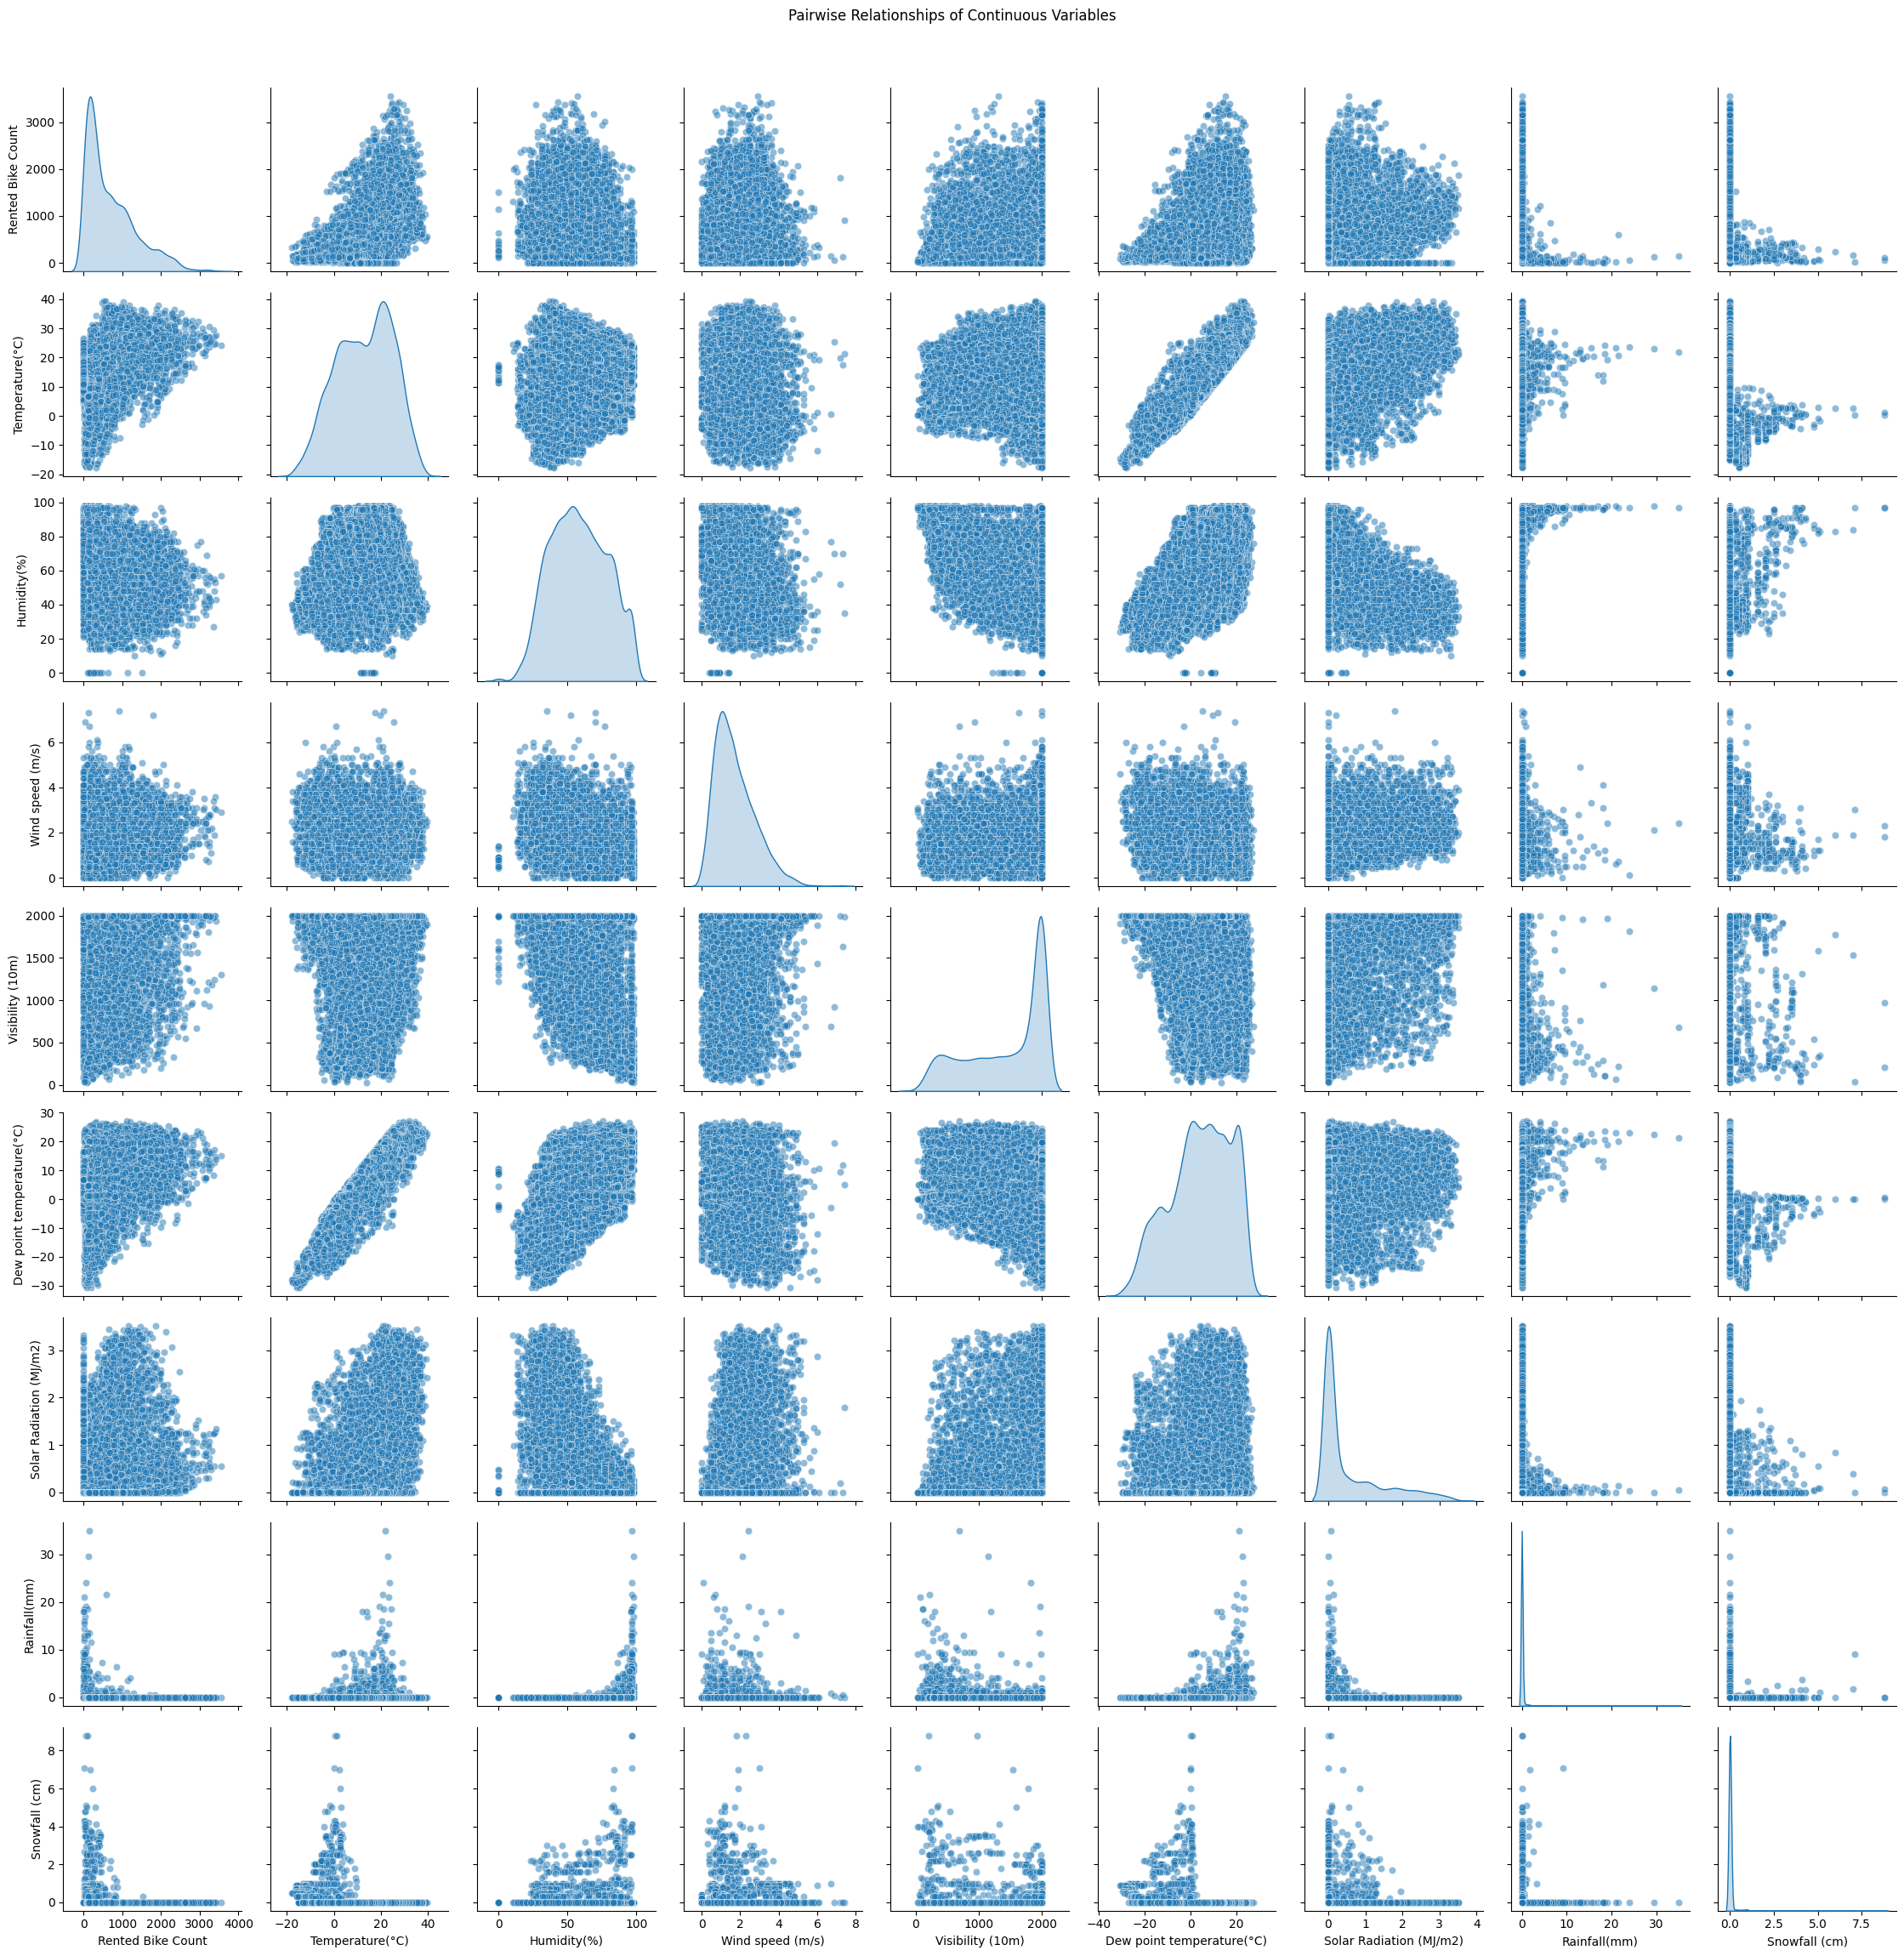

In [10]:
sns.pairplot(df[continuous_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships of Continuous Variables', y=1.02)
plt.tight_layout()
plt.show()

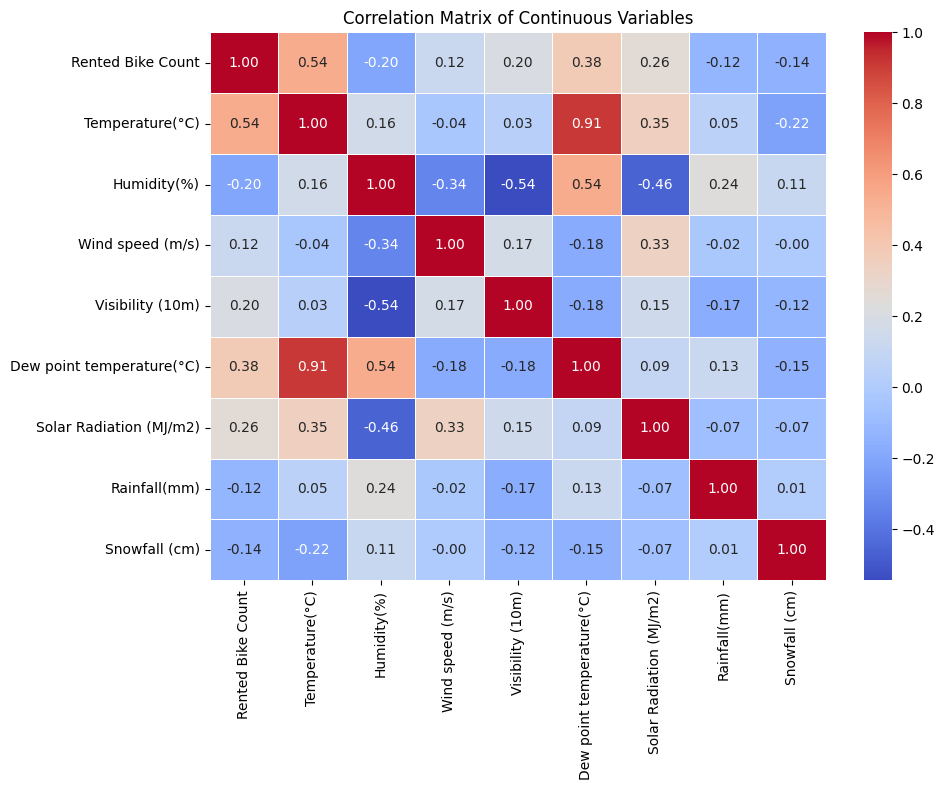

In [11]:
corr_matrix = df[continuous_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()

`Rented Bike Count` shows its strongest positive associations with `Temperature` (0.54) and `Dew Point Temperature` (0.38), though neither relationship is particularly strong. `Rented Bike Count` also has slight negative associations with `Humidity` (-0.20), `Rainfall` (-0.12), and `Snowfall` (-0.14). `Visibility` and `Humidity` are negatively correlated (-0.54), as well as `Solar Radiation` and `Humidity` (-0.46). `Dew Point Temperature` and `Humidity` have a relatively strong positive correlation (0.54). `Temperature` and `Dew Point Temperature` have the strongest correlation, positive (0.91).

We can see that `Rented Bike Count` does not have any strong positive associations with any continuous explanatory variables. 

#### Binary Variables

In [12]:
print(df[binary_cols].describe(include='all'))

           Holiday Functioning Day
count         8760            8760
unique           2               2
top     No Holiday             Yes
freq          8328            8465


## 1 Best Normal Linear Model

In [13]:
df_encoded = pd.get_dummies(df.drop(['Date', 'DateTime', 'Date_only'], axis=1), columns=['Hour', 'Seasons', 'Holiday', 'Functioning Day'], drop_first=True, dtype=int)
df_explanatory = df_encoded.drop(['Rented Bike Count'], axis=1)

### a. Fitting the Model

#### All Explanatory Variables Included

In [14]:
X_all = df_explanatory
Y = df_encoded['Rented Bike Count']
X_all = sm.add_constant(X_all)  # Add intercept term
model_all = sm.OLS(Y, X_all).fit()
print(model_all.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     474.6
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        15:26:34   Log-Likelihood:                -64349.
No. Observations:                8760   AIC:                         1.288e+05
Df Residuals:                    8723   BIC:                         1.290e+05
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [15]:
all_Y_pred = model_all.predict(X_all)
all_mse = mean_squared_error(Y, all_Y_pred)
all_r2 = r2_score(Y, all_Y_pred)
print(f'Mean Squared Error: {all_mse:.2f}')
print(f'R-squared: {all_r2:.4f}')

Mean Squared Error: 140584.63
R-squared: 0.6620


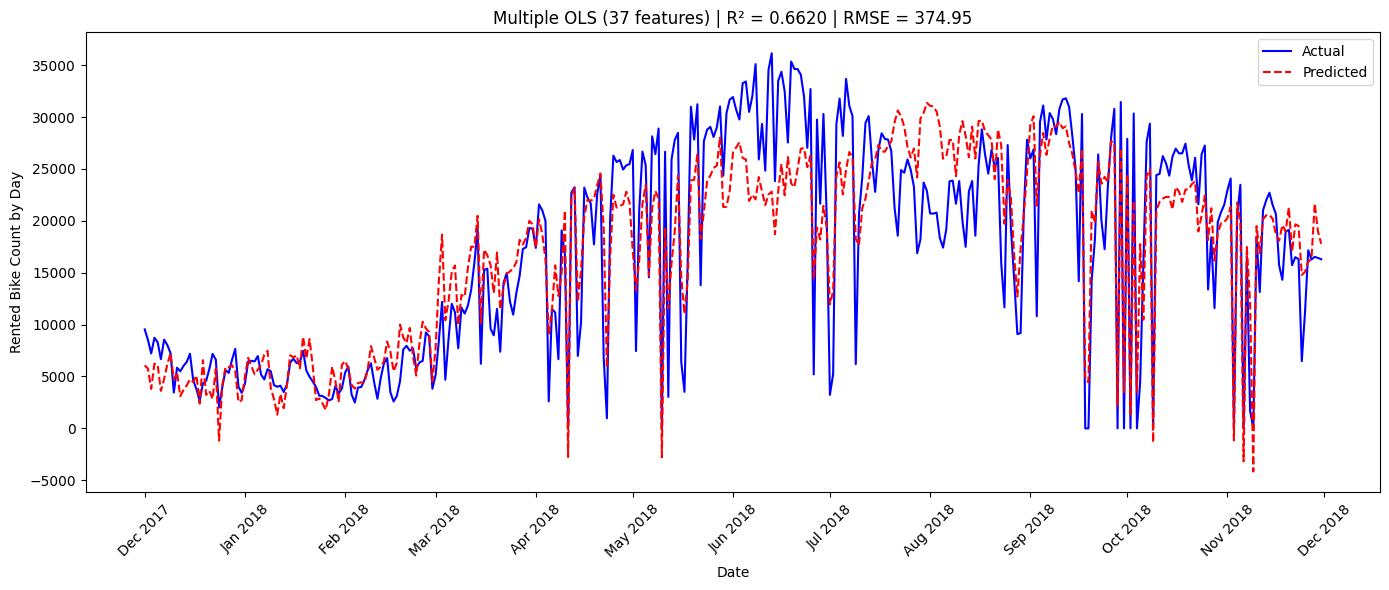

In [16]:
all_plot_df = pd.DataFrame({'Date': df['Date_only'], 'Actual': Y, 'Predicted': all_Y_pred})
all_daily = (all_plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum()
                .reset_index()
                .sort_values('Date'))

plt.figure(figsize=(14,6))

plt.plot(all_daily['Date'], all_daily['Actual'], label='Actual', color='blue')
plt.plot(all_daily['Date'], all_daily['Predicted'], label='Predicted', color='red', linestyle='--')

# --- KEY PART: monthly ticks ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())          # one tick per month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format: Jan 2018, Feb 2018, ...

plt.title(f"Multiple OLS ({X_all.shape[1]} features) | R² = {all_r2:.4f} | RMSE = {np.sqrt(all_mse):.2f}")
plt.xlabel("Date")
plt.ylabel("Rented Bike Count by Day")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Feature selection
(performed in R, see please additional materials)

In the model with **all** explanatory models included, we can see that `Visibility` and  `Wind speed` are not significant predictors.

**Forward Selection**: Step:  $AIC=103908.4$

`Rented Bike Count` ~ `Temperature` + `Hour` + `Functioning Day` + 
    `Humidity` + `Seasons` + `Rainfall` + `Solar Radiation` + 
    `Holiday` + `Dew Point Temperature` + `Snowfall`

| Term                  | Df | Sum of Sq |       RSS    |   AIC  |
|-----------------------|----|-----------|--------------|--------|
| <none>                |    |           | 1231682903   | 103908 |
| `Visibility`    | 1  |   154303  | 1231528601   | 103909 |
| `Wind Speed`    | 1  |    16316  | 1231666587   | 103910 |

**Backward Selection**: Step:  $AIC=103908.4$

`Rented Bike Count` ~ `Hour` + `Temperature` + `Humidity` + 
    `Dew Point Temperature` + `Solar Radiation` + 
    `Rainfall` + `Snowfall` + `Seasons` + `Holiday` + `Functioning Day`

| Term                               | Df | Sum of Sq  | RSS         | AIC    |
|------------------------------------|----|------------|-------------|--------|
| <none>                             |    |            | 1231682903  | 103908 |
| `Temperature`                  | 1  | 1134633    | 1232817536  | 103914 |
| `Snowfall`                    | 1  | 1172965    | 1232855868  | 103915 |
| `Dew Point Temperature`        | 1  | 2657341    | 1234340244  | 103925 |
| `Holiday`                            | 1  | 5549734    | 1237232637  | 103946 |
| `Solar Radiation`          | 1  | 10033817   | 1241716721  | 103977 |
| `Humidity`                      | 1  | 19243708   | 1250926611  | 104042 |
| `Rainfall`                     | 1  | 34029648   | 1265712551  | 104145 |
| `Seasons`                            | 3  | 95724751   | 1327407655  | 104558 |
| `Functioning Day`                  | 1  | 229762878  | 1461445781  | 105405 |
| `Hour`                               | 23 | 701524297  | 1933207200  | 107811 |

**Stepwise Selection**: $Step:  AIC=103908.4$

`Rented Bike Count` ~ `Hour` + `Temperature` + `Humidity(%)` + 
    `Dew Point Temperature` + `Solar Radiation` + 
    `Rainfall` + `Snowfall` + `Seasons` + `Holiday` + `Functioning Day`

| Term                               | Df | Sum of Sq  | RSS         | AIC    |
|------------------------------------|----|------------|-------------|--------|
| <none>                             |    |            | 1231682903  | 103908 |
| `Visibility`                 | 1  |   154303   | 1231528601  | 103909 |
| `Wind Speed`                 | 1  |    16316   | 1231666587  | 103910 |
| `Temperature`                  | 1  |  1134633   | 1232817536  | 103914 |
| `Snowfall`                    | 1  |  1172965   | 1232855868  | 103915 |
| `Dew Point Temperature`        | 1  |  2657341   | 1234340244  | 103925 |
| `Holiday `                           | 1  |  5549734   | 1237232637  | 103946 |
| `Solar Radiation`          | 1  | 10033817   | 1241716721  | 103977 |
| `Humidity`                      | 1  | 19243708   | 1250926611  | 104042 |
| `Rainfall`                     | 1  | 34029648   | 1265712551  | 104145 |
| `Seasons`                            | 3  | 95724751   | 1327407655  | 104558 |
| `Functioning Day`                  | 1  | 229762878  | 1461445781  | 105405 |
| `Hour`                               | 23 | 701524297  | 1933207200  | 107811 |




#### Best Model

`Rented Bike Count` ~ 
  `Hour` +
  `Temperature` +
  `Humidity` +
  `Dew Point Temperature` +
  `Solar Radiation` +
  `Rainfall` +
  `Snowfall` +
  `Seasons` +
  `Holiday` +
  `Functioning Day`


In [17]:
X_best = df_explanatory.drop(['Wind speed (m/s)', 'Visibility (10m)'], axis=1)
Y = df_encoded['Rented Bike Count']
X_best = sm.add_constant(X_best)  # Add intercept term
model_best = sm.OLS(Y, X_best).fit()
print(model_best.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     502.6
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        15:26:34   Log-Likelihood:                -64349.
No. Observations:                8760   AIC:                         1.288e+05
Df Residuals:                    8725   BIC:                         1.290e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [18]:
best_Y_pred = model_best.predict(X_best)
best_mse = mean_squared_error(Y, best_Y_pred)
best_r2 = r2_score(Y, best_Y_pred)
print(f'Mean Squared Error: {best_mse:.2f}')
print(f'R-squared: {best_r2:.4f}')

Mean Squared Error: 140603.07
R-squared: 0.6620


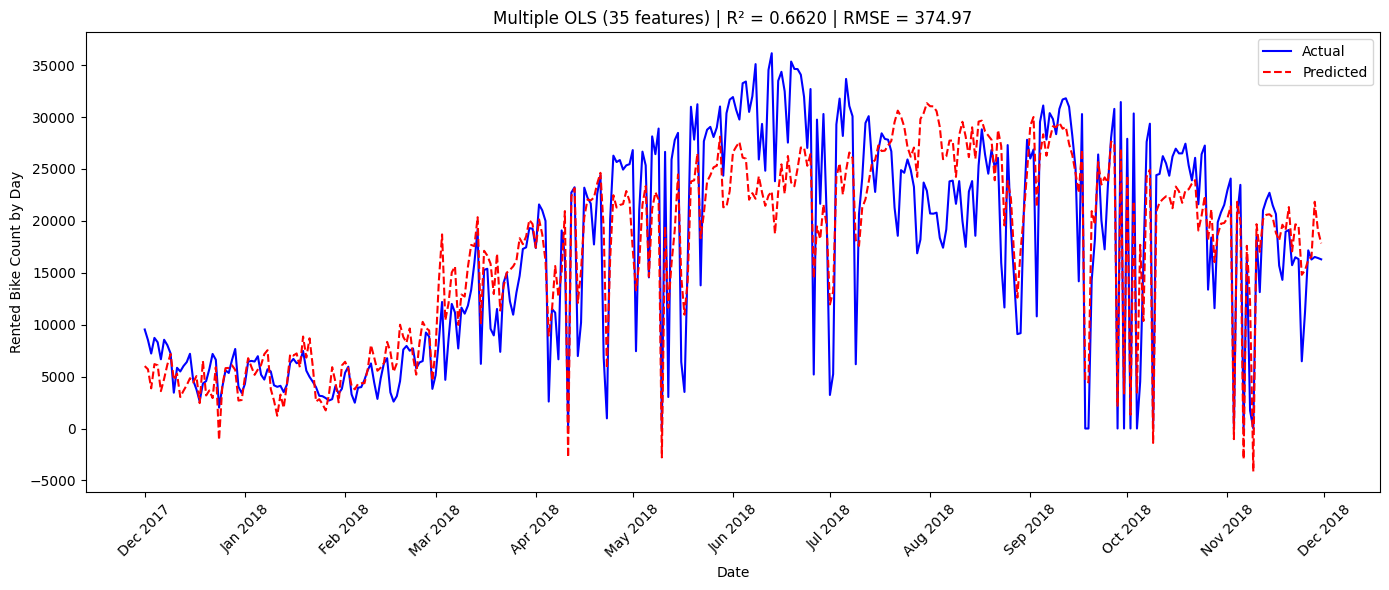

In [19]:
best_plot_df = pd.DataFrame({'Date': df['Date_only'], 'Actual': Y, 'Predicted': best_Y_pred})
best_daily = (best_plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum()
                .reset_index()
                .sort_values('Date'))

plt.figure(figsize=(14,6))

plt.plot(best_daily['Date'], best_daily['Actual'], label='Actual', color='blue')
plt.plot(best_daily['Date'], best_daily['Predicted'], label='Predicted', color='red', linestyle='--')

# --- KEY PART: monthly ticks ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())          # one tick per month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format: Jan 2018, Feb 2018, ...

plt.title(f"Multiple OLS ({X_best.shape[1]} features) | R² = {best_r2:.4f} | RMSE = {np.sqrt(best_mse):.2f}")
plt.xlabel("Date")
plt.ylabel("Rented Bike Count by Day")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The second model (excludes `Wind Speed` and `Visibility`) is the **best** model because it produces essentially the same model (identical $R^2$, AIC, BIC; nearly identical RMSE) with *less* predictors (2 less).

### b. Model Interpretation

Feature selection (all three methods; forward, backward, and step-wise) all confirm findings in the first model (includes **all** explanantory variables) that `Wind Speed` and `Visibility` are not significant predictors. The second model (excludes `Wind Speed` and `Visibilty`) confirms that the remaining predictors are all significant predictors.

In the second model (excludes `Wind Speed` and `Visibility`), $R^2 = 0.662$.
- `Functioning Day` has the largest single effect on the model (coeff: $+933.1$, CI: $[887.7, 978.4]$). Because all non-functioning days have zero rentals, the model estimates a large positive coefficient that reflects the difference in rental activity between functioning and non-functioning days.
- In terms of weather characteristics, for every $1\text{\textdegree}C$ increase in `Temperature`, `Rented Bike Count` increases by $9$ rented bikes (coeff: $+9.24$, CI: $[2.85, 15.63]$). For every $1\text{\textdegree}C$ increase in `Dew Point Temperature`, `Rented Bike Count` increases by almost $15$ rented bikes (coeff: $+14.65$, CI: $[8.03, 21.28]$). However, for every percent increase in `Humidity`, `Rented Bike Count` decreases by $10$ rented bikes (coeff: $-10.18$, CI: $[-11.89, -8.47]$). Increase in `Solar Radiation` significantly increases `Rented Bike Count` (coeff: $+83.0$, CI: $[63.7, 102.3]$), while increase in `Rainfall` significantly decreases `Rented Bike Count` (coeff: $-58.02$, CI: $[-65.3, -50.7]$). Surprisingly, `Snowfall` actually increases `Rented Bike Count` (coeff: $+28.08$, CI: $[8.99, 47.17]$). In general, the model shows that better weather conditions are associated with a greater number of bike rentals.
- The model shows that `Hour` has a significant relationship with `Rented Bike Count` with clear spikes at the hours of **8** (coeff: $+476$, CI: $[421, 531]$), **18** (coeff: $+755$, CI: $[700, 811]$), and **19** (coeff: $+505$, CI: $[451, 560]$) and clear drops at the hours of **4** (coeff: $-355$, CI: $[-410, -301]$) and **5** (coeff: $-342$, CI: $[-398, -288]$) compared to midnight. The hours of **9** (coeff: $+12$, CI: $[-44, 69]$) and **16** (coeff: $+33$, CI: $[-25, 92]$) are not significant compared to midnight, which means number of rented bikes is relatively the same at the hours of **9**, **16**, and **0** (midnight). As expected, the number of rented bikes peak during the morning hours before work (8-9 am) and the afternoon/evening hours after work (6-7 pm), and there is a nightly low point during the morning hours of 4 am and 5 am.
- The model shows that **Autumn** is the peak `Season` for `Rented Bike Count` with number of bike rentals dropping by 156 in the **Summer** (coeff: $-156$, CI: $[-186, -127]$), 160 in the **Spring** (coeff: $-160$, CI: $[-184, -138]$), and 367 in the **Winter** (coeff: $-367$, CI: $[-401, -334]$).
- `Holiday` also has a significantly large single effect on the model (coeff: $+117$, CI: $[81, 154]$), indicating that compared to holidays, non-holidays generally see an increase of 117 rented bikes.

### c. Model Diagnostics

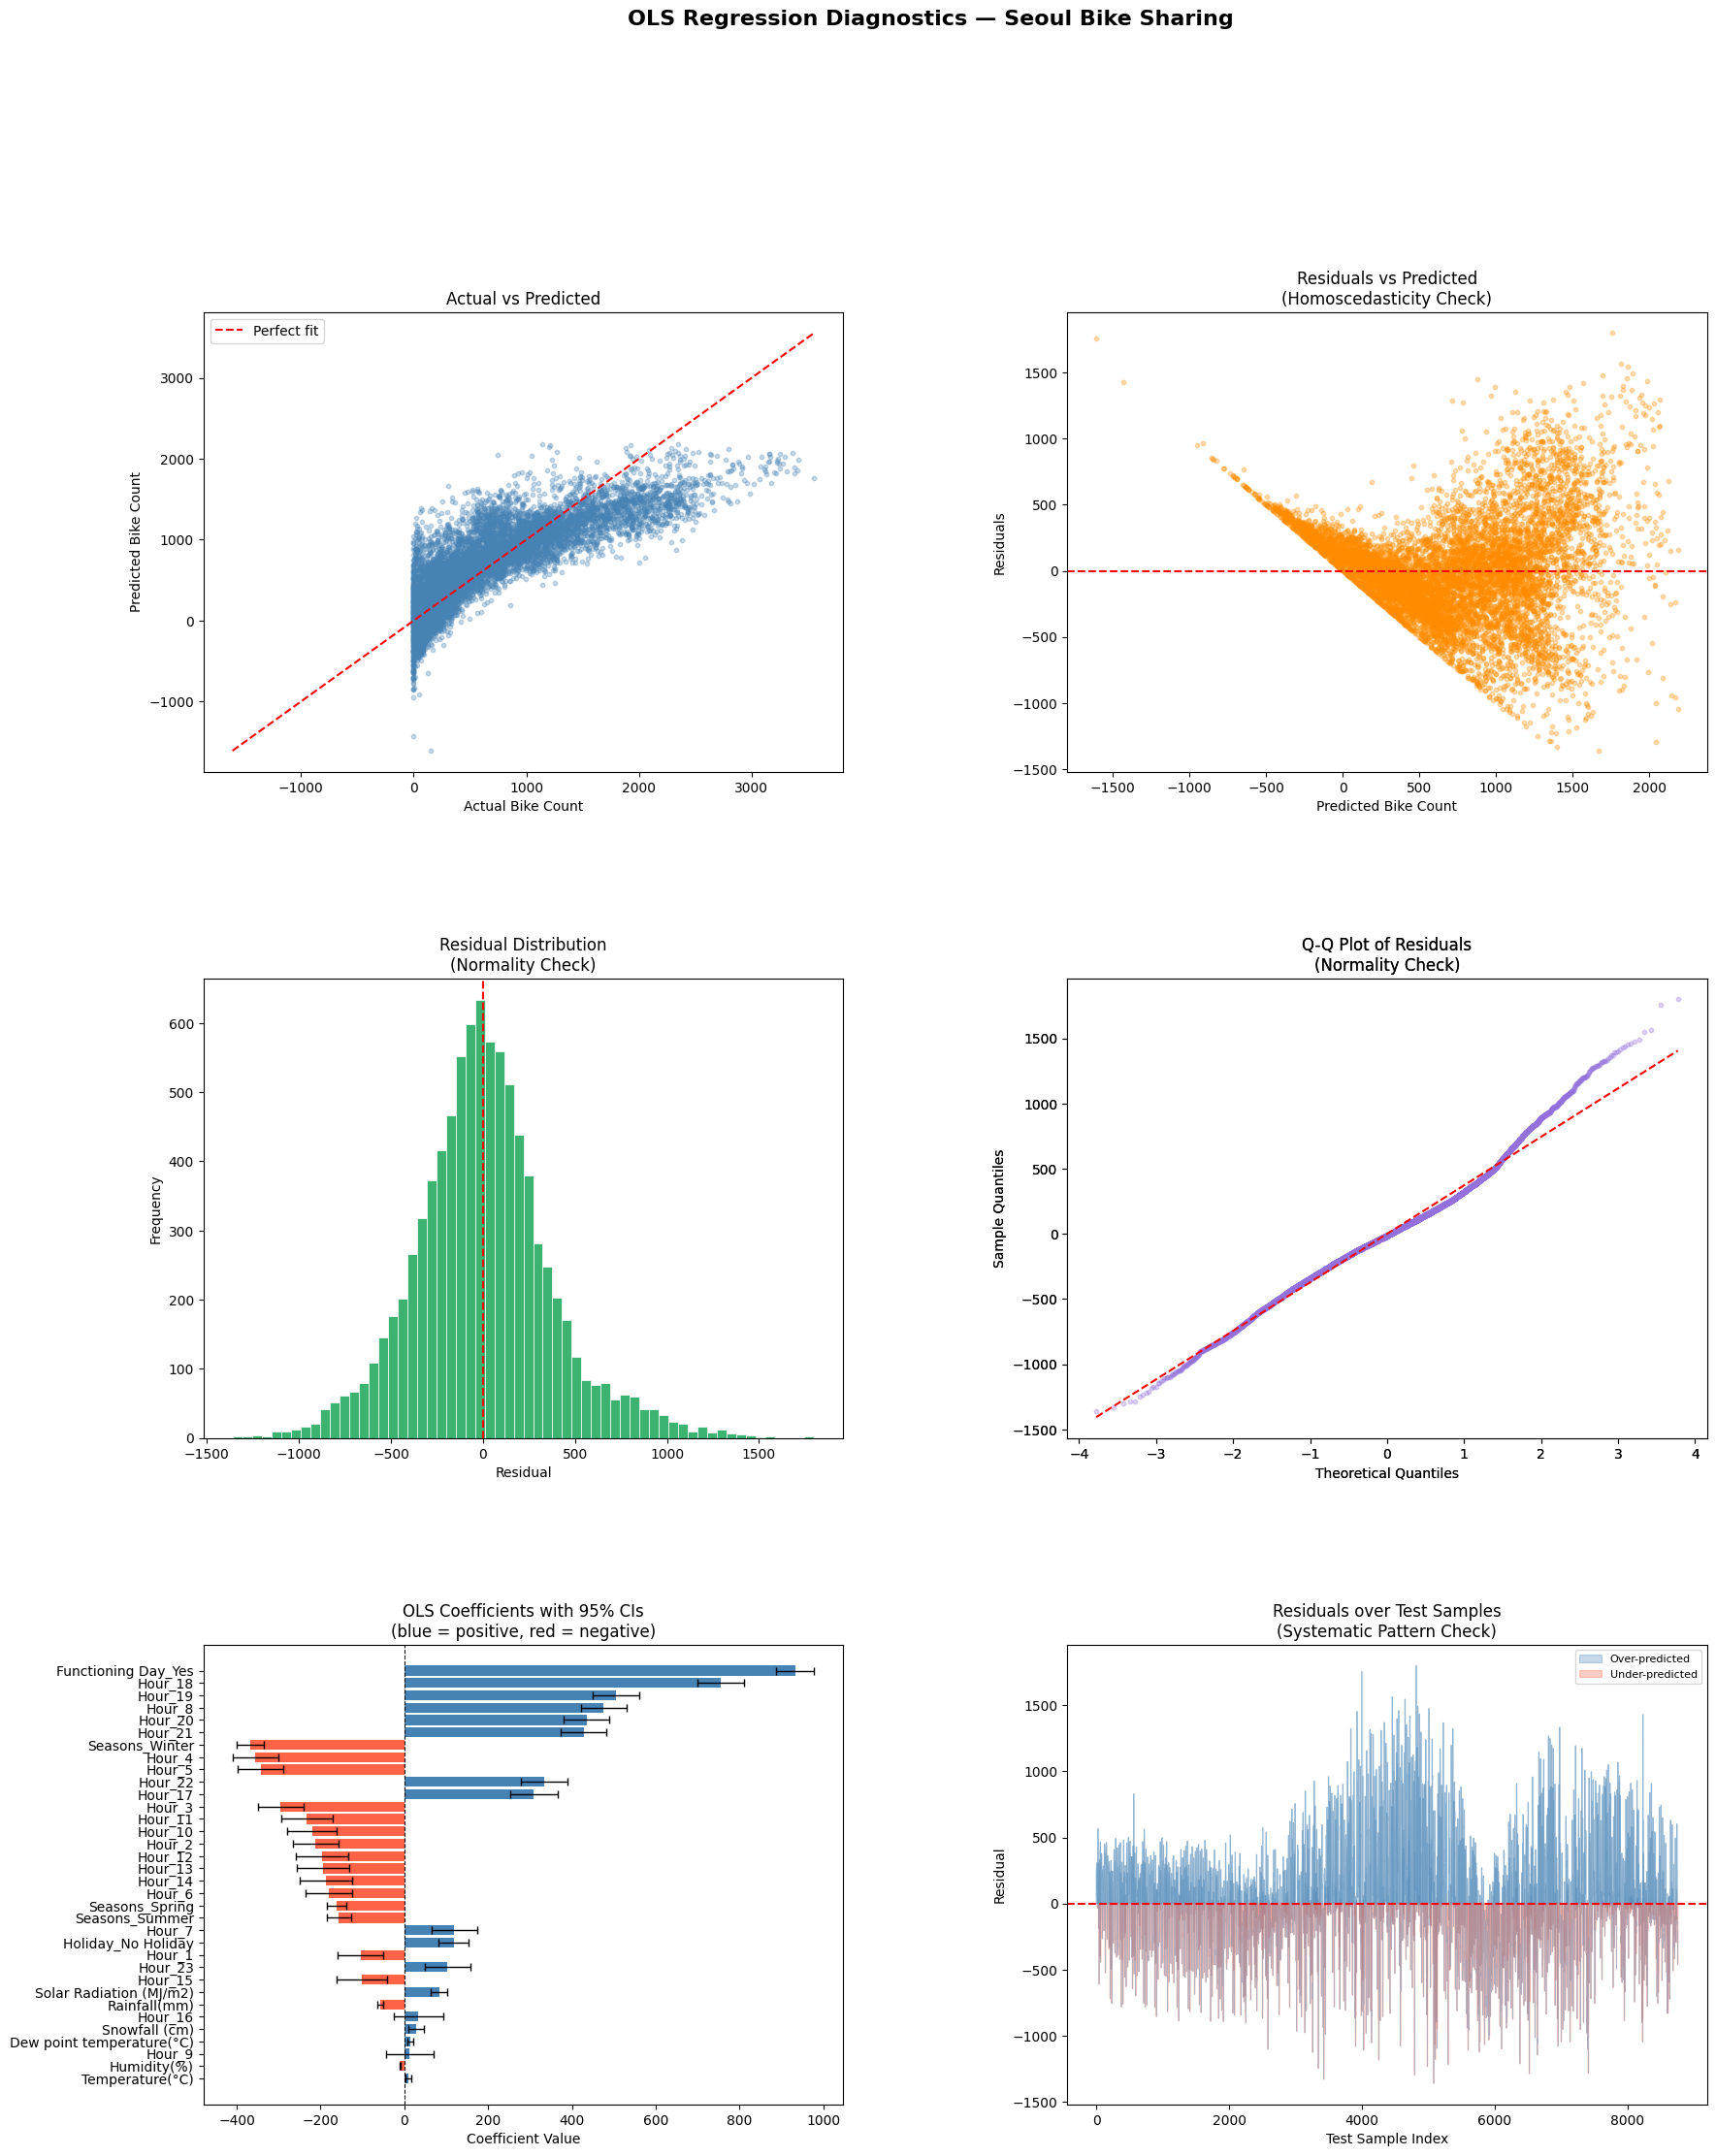

In [28]:
best_model_residuals = Y - best_Y_pred

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Actual vs Predicted ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(Y, best_Y_pred, alpha=0.3, color='steelblue', s=10)
lims = [min(Y.min(), best_Y_pred.min()), max(Y.max(), best_Y_pred.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax1.set_xlabel('Actual Bike Count')
ax1.set_ylabel('Predicted Bike Count')
ax1.set_title('Actual vs Predicted')
ax1.legend()

# ── 2. Residuals vs Predicted (Homoscedasticity check) ─────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(best_Y_pred, best_model_residuals, alpha=0.3, color='darkorange', s=10)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted Bike Count')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals vs Predicted\n(Homoscedasticity Check)')

# ── 3. Residual Distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(best_model_residuals, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Residual')
ax3.set_ylabel('Frequency')
ax3.set_title('Residual Distribution\n(Normality Check)')

# ── 4. Q-Q Plot ─────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(best_model_residuals, dist='norm')
ax4.scatter(osm, osr, alpha=0.3, color='mediumpurple', s=10)
ax4.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Sample Quantiles')
ax4.set_title(f'Q-Q Plot of Residuals\n(Normality Check)')

# ── 4. Q-Q Plot ─────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(best_model_residuals, dist='norm')
ax4.scatter(osm, osr, alpha=0.3, color='mediumpurple', s=10)
ax4.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Sample Quantiles')
ax4.set_title(f'Q-Q Plot of Residuals\n(Normality Check)')

# ── 5. Top Feature Coefficients (with confidence intervals) ─────────────────
ax5 = fig.add_subplot(gs[2, 0])
coef_summary = model_best.summary2().tables[1].drop('const', errors='ignore')
coef_summary = coef_summary.reindex(
    coef_summary['Coef.'].abs().sort_values(ascending=True).index
)
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_summary['Coef.']]
ax5.barh(coef_summary.index, coef_summary['Coef.'], color=colors,
         xerr=(coef_summary['Coef.'] - coef_summary['[0.025']).abs(),
         capsize=3, error_kw={'linewidth': 1})
ax5.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax5.set_xlabel('Coefficient Value')
ax5.set_title('OLS Coefficients with 95% CIs\n(blue = positive, red = negative)')

# ── 6. Residuals over Time ──────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(np.arange(len(best_model_residuals)), best_model_residuals.values, alpha=0.4,
         color='steelblue', linewidth=0.5)
ax6.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax6.fill_between(np.arange(len(best_model_residuals)), best_model_residuals.values, 0,
                 where=(best_model_residuals.values > 0), alpha=0.3, color='steelblue',
                 label='Over-predicted')
ax6.fill_between(np.arange(len(best_model_residuals)), best_model_residuals.values, 0,
                 where=(best_model_residuals.values < 0), alpha=0.3, color='tomato',
                 label='Under-predicted')
ax6.set_xlabel('Test Sample Index')
ax6.set_ylabel('Residual')
ax6.set_title('Residuals over Test Samples\n(Systematic Pattern Check)')
ax6.legend(fontsize=8)

plt.suptitle('OLS Regression Diagnostics — Seoul Bike Sharing', 
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('ols_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


- **Clear heteroscedasticity**
- **Non-normal residuals**
- Predictors generally behave as expected

### d. Model Strengths and Limitations

The model captures the general trends well, but could still be greatly improved. Non-linear models would probably be better.

## 2 Simplest Linear Model

### Temperature
**Temperature** has the strongest association with **Rented Bike Count** at each hour.

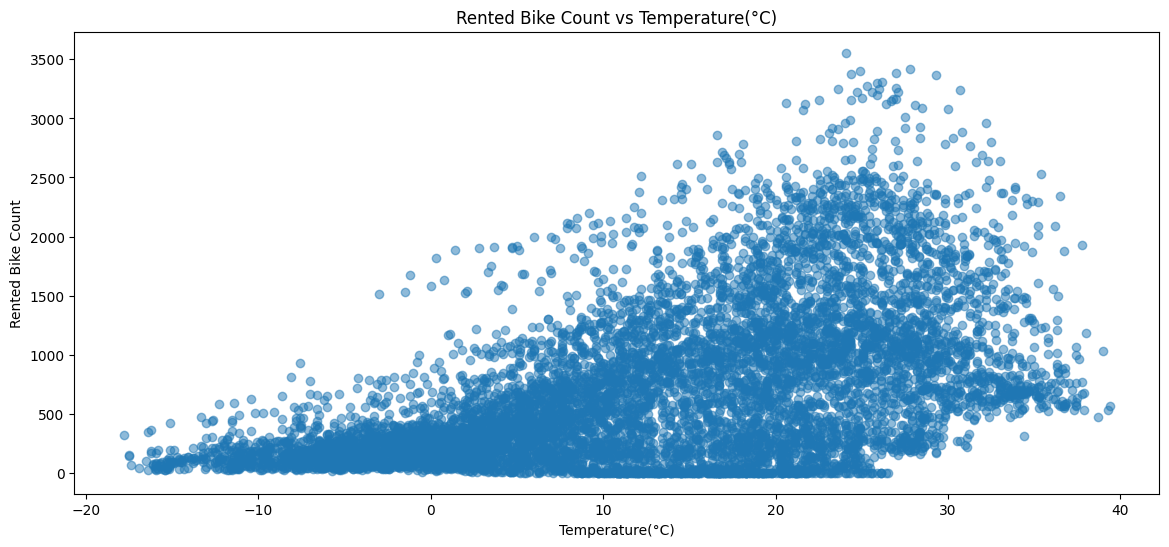

In [21]:
plt.figure(figsize=(14,6))

plt.scatter(df_explanatory['Temperature(°C)'], Y, alpha=0.5)
plt.title('Rented Bike Count vs Temperature(°C)')
plt.xlabel('Temperature(°C)')
plt.ylabel('Rented Bike Count')
plt.show()

#### a. Fitting the Model

In [22]:
X_simple = df_explanatory['Temperature(°C)']
Y = df_encoded['Rented Bike Count']
X_simple = sm.add_constant(X_simple)
model_simple = sm.OLS(Y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     3578.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        15:26:36   Log-Likelihood:                -67600.
No. Observations:                8760   AIC:                         1.352e+05
Df Residuals:                    8758   BIC:                         1.352e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             329.9525      8.541     

In [23]:
simple_Y_pred = model_simple.predict(X_simple)
simple_mse = mean_squared_error(Y, simple_Y_pred)
simple_r2 = r2_score(Y, simple_Y_pred)
print(f'Mean Squared Error: {simple_mse:.2f}')
print(f'R-squared: {simple_r2:.4f}')

Mean Squared Error: 295323.04
R-squared: 0.2900


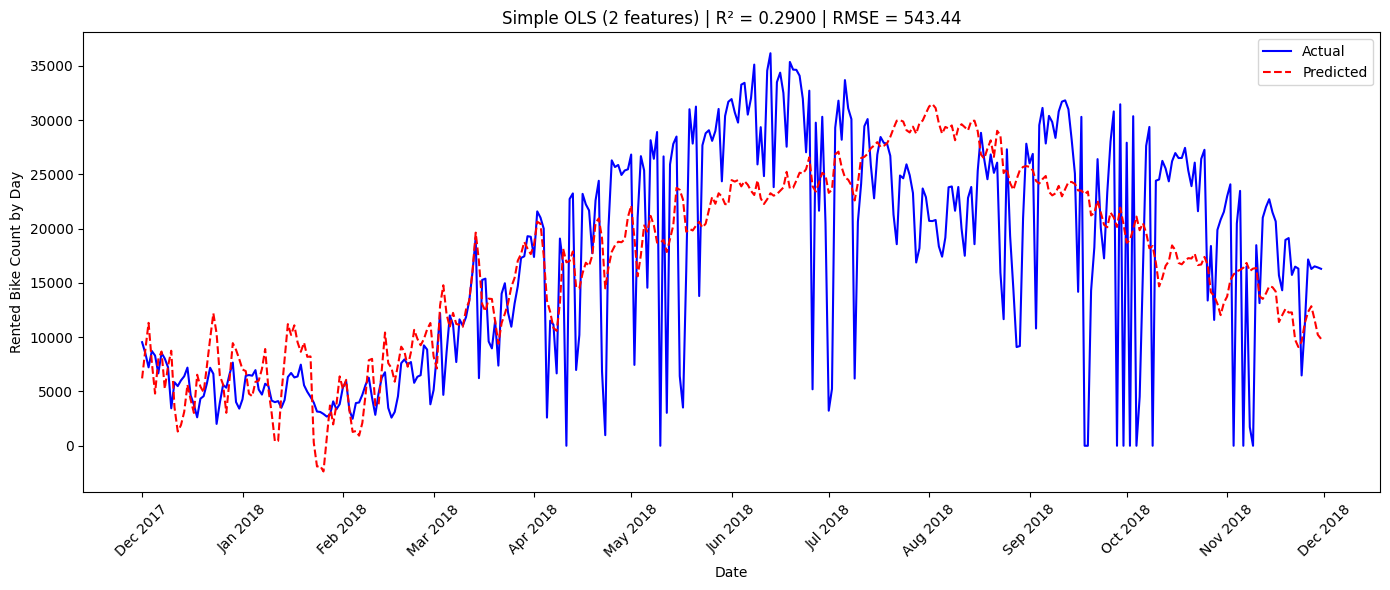

In [24]:
simple_plot_df = pd.DataFrame({'Date': df['Date_only'], 'Actual': Y, 'Predicted': simple_Y_pred})
simple_daily = (simple_plot_df.groupby('Date')[['Actual', 'Predicted']]
                .sum()
                .reset_index()
                .sort_values('Date'))

plt.figure(figsize=(14,6))

plt.plot(simple_daily['Date'], simple_daily['Actual'], label='Actual', color='blue')
plt.plot(simple_daily['Date'], simple_daily['Predicted'], label='Predicted', color='red', linestyle='--')

# --- KEY PART: monthly ticks ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())          # one tick per month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format: Jan 2018, Feb 2018, ...

plt.title(f"Simple OLS ({X_simple.shape[1]} features) | R² = {simple_r2:.4f} | RMSE = {np.sqrt(simple_mse):.2f}")
plt.xlabel("Date")
plt.ylabel("Rented Bike Count by Day")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


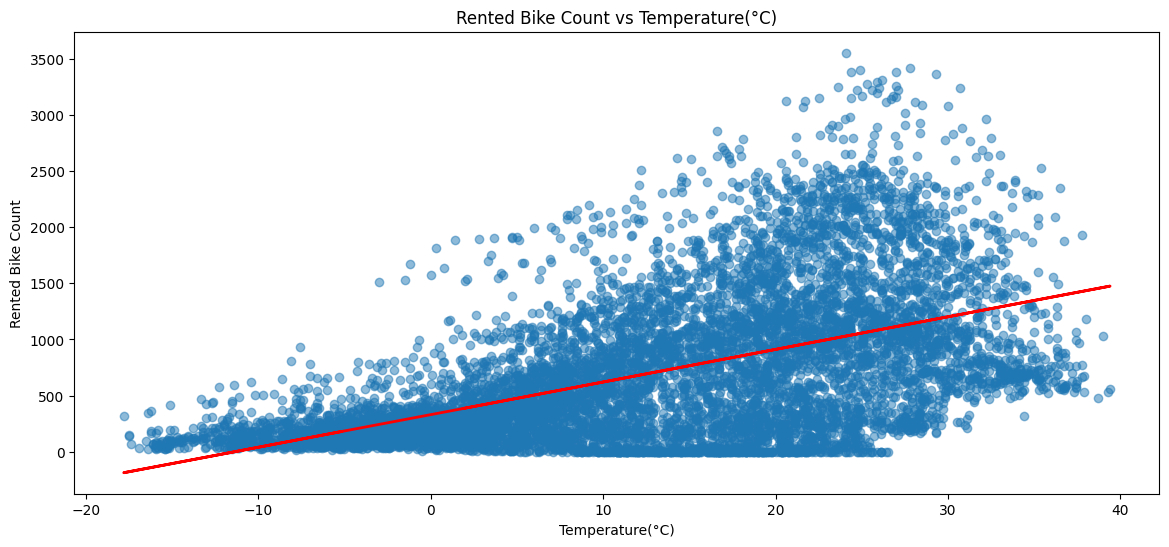

In [25]:
plt.figure(figsize=(14,6))

# Scatter of actual data
plt.scatter(df_explanatory['Temperature(°C)'], Y, alpha=0.5, label='Actual')

# Prediction line
plt.plot(df_explanatory['Temperature(°C)'], simple_Y_pred, color='red', linewidth=2, label='Predicted')

plt.title('Rented Bike Count vs Temperature(°C)')
plt.xlabel('Temperature(°C)')
plt.ylabel('Rented Bike Count')
plt.show()

#### b. Model Interpretation

According to this simple model, a 1 degree C increase in `Temperature` is associated with an increase of $29$ in `Rented Bike Count` per hour.

#### c. Model Strengths and Limitations

The simple model captures the general trend of increasing `Rented Bike Count` as `Temperature` increases.

## 3 Generalized Linear Models (GLMs)

### a. Fitting the Model

### b. Comparison to Previous Models

### c. Model Interpretation

### d. Model Diagnostics